In [1]:
!pip install ECOS
import pandas as pd
import numpy as np 
import cvxpy as cp
import gl_reg as glr

In [2]:
signals = pd.read_csv("/Users/chrisduran/Desktop/315/NOAA_increased.csv")

In [3]:
import os
os.listdir() 
import cvxpy as cp

In [4]:
X_REAL_DATA = signals
signal_prefix = 'TMAX'
signal_cols = [col for col in X_REAL_DATA.columns if col.startswith(signal_prefix)]
X_noisy = X_REAL_DATA[signal_cols].to_numpy()  

# Define regressors
regressor_prefixes = ['ELEVATION', 'TMIN']
P = []

for prefix in regressor_prefixes:
    cols = [col for col in X_REAL_DATA.columns if col.startswith(prefix)]
    reg_matrix = X_REAL_DATA[cols].to_numpy()
    
    # Handle static variables (like elevation)
    if reg_matrix.shape[1] == 1:
        reg_matrix = np.repeat(reg_matrix, X_noisy.shape[1], axis=1)
    
    P.append(reg_matrix)

ones_matrix = np.ones_like(X_noisy) 
P.append(ones_matrix)

   ###################################

from sklearn import metrics

def lowertrian(Lap):
                                                ##Extract the lower triangular part of the Laplacian
    N = Lap.shape[0]
    return Lap[np.tril_indices(N, k=-1)]

def vec(S):
    return S.flatten('F') 

def Pbeta(P, b):
    """Construct the signal from regressors and beta"""
    R = sum([P[i] * b[i] for i in range(len(P))])
    return vec(R)

def pstack(P):
    """Stack regressor arrays into one tall matrix"""
    Pvec = [p.ravel(order="F") for p in P]
    return np.stack(Pvec, axis=1)

def prune(L,threshold=1e-3):
    """Zero out small values in Laplacian"""
    temp = L.copy()
    temp[np.abs(temp) < threshold] = 0
    return temp


In [5]:
def optimize_L(hatS, P, beta, w1, w2):
    """Optimize the Laplacian matrix"""
    N, n = hatS.shape
    L = cp.Variable((N, N), symmetric=True)
    constraints = [
        cp.trace(L) == N,
        L - cp.diag(cp.diag(L)) <= 0,
        cp.diag(L) >= 0,
        L @ np.ones((N, 1)) == 0 ]
    
    x = vec(hatS) - Pbeta(P, beta)
    D = cp.kron(np.identity(n), L)
    
    objective = cp.Minimize(w1 * cp.quad_form(x, D) + w2 * cp.norm(L, 'fro') ** 2)
    cp.Problem(objective, constraints).solve(solver= cp.ECOS)
   
    return L.value

def optimize_hatS(L, P, beta, S, w1):
    """Optimize the estimated signal"""
    N, n = S.shape
    InXL = np.kron(np.identity(n), L) 
    term1 = w1 * InXL + np.identity(N * n)
    term2 = np.linalg.pinv(term1) 
    term3 = vec(S) + w1 * (InXL @ Pbeta(P, beta))
    return (term2 @ term3).reshape((N, n), order="F") 

    
def optimize_beta(P, L, hatS):
    """Optimize the regression coefficients"""
    n = hatS.shape[1]
    InXL = np.kron(np.identity(n), L)
    Ptemp = pstack(P)
    term1 = Ptemp.T @ InXL @ Ptemp
    term2 = np.linalg.pinv(term1) @ Ptemp.T  
    term3 = InXL @ vec(hatS)
    return term2 @ term3

In [6]:
def GSPRegression(X_noisy, P, w1, w2, max_iter=100, threshhold=0.0001):
    """
    Graph signal regression with Laplacian learning.
    Returns: [Learned Laplacian, Estimated Signal, Beta, Untouched Laplacian]
    """
    N, n = X_noisy.shape
    hatS = X_noisy.copy()
    hatS_0 = X_noisy.copy()
    objective = [0] * max_iter
    beta = np.zeros((len(P), 1))
    

    for i in range(max_iter):
        L = optimize_L(hatS, P, beta, w1, w2)
        hatS = optimize_hatS(L, P, beta, X_noisy, w1)
        beta = optimize_beta(P, L, hatS)

        x = vec(hatS) - Pbeta(P, beta)
        D = np.kron(np.identity(n), L)
        arg1 = np.linalg.norm(hatS - hatS_0, 'fro') ** 2
        arg2 = w1 * x.T @ D @ x
        arg3 = w2 * np.linalg.norm(L, 'fro') ** 2
        objective[i] = arg1 + arg2 + arg3

        if i >= 2 and abs(objective[i] - objective[i - 1]) < 1e-4:
            break
        
    return [prune(L, threshhold), hatS, beta, L]


In [7]:
def metricsprf(L0, L):
    """Compute precision,F1 score and NMI between true and learned Laplacians"""
    edges_groundtruth = lowertrian(L0) != 0
    edges_learned = lowertrian(L) != 0
    
    if np.sum(edges_learned) == 0:
        return (-1, -1, -1, -1)

    precision = metrics.precision_score(edges_groundtruth, edges_learned)
    recall = metrics.recall_score(edges_groundtruth, edges_learned)
    fscore = metrics.f1_score(edges_groundtruth, edges_learned)
    nmi = metrics.normalized_mutual_info_score(edges_groundtruth, edges_learned)
    return (precision, recall, fscore, nmi)

    

In [8]:
for i, Pi in enumerate(P):
    print(f"P[{i}].shape = {Pi.shape}")

P[0].shape = (20, 90)
P[1].shape = (20, 90)
P[2].shape = (20, 90)


In [9]:
#print("L and L_hat equal?", np.allclose(L, prune(L,threshold=0.0001)))
#print("Difference Fro norm:", np.linalg.norm(L - prune(L,threshold=0.0001), 'fro'))

NameError: name 'L' is not defined

In [12]:
def Pbeta(P, beta): 
    #for i, Pi in enumerate(P):
     #   print(f"P[{i}].shape = {Pi.shape}")
    P_stack = np.column_stack([
        np.array(Pi).flatten(order="F") for Pi in P ])
    beta = beta.flatten()
    return P_stack @ beta

w1 = 0.01  # smoothness penalty
w2 = 0.05  # sparsity penalty

L_hat, S_hat, beta_hat, raw_L = GSPRegression(X_noisy, P, w1, w2)

In [13]:
L = GSPRegression(X_noisy,P, w1,w2 )[0]

In [75]:
#np.save('L.npy', L) 
# L = np.load('L.npy') ##recall saved L run 
print("Difference Fro norm:", np.linalg.norm(L - L_hat, 'fro'))

Difference Fro norm: 0.0


In [14]:
D = pd.read_csv("/Users/chrisduran/Desktop/315/NOAA_dist_increased.csv")

In [15]:
L = np.array(L, dtype=float)  

## Distance Matrix (Mod. in R, threshold in meters, compare)
threshold_meters = 190_000
adj_D_df = (D.iloc[:, 1:] < threshold_meters).astype(int)
adj_D = adj_D_df.to_numpy()  
np.fill_diagonal(adj_D, 0)


adj_L = np.abs(L_hat.copy())
np.fill_diagonal(adj_L, 0)

In [16]:
degrees = np.sum(adj_D, axis=1)
D_mat = np.diag(degrees)

#Normalized 
L_norm = (L.shape[0] / np.trace(L)) * L

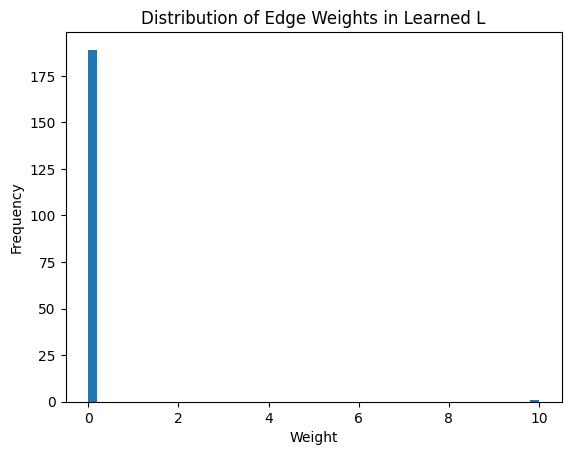

In [17]:
import matplotlib.pyplot as plt

edge_weights = np.abs(L[np.tril_indices_from(L, k=-1)])
plt.hist(edge_weights, bins=50)
plt.title("Distribution of Edge Weights in Learned L")
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.show()


In [18]:
import networkx as nx
import matplotlib.pyplot as plt


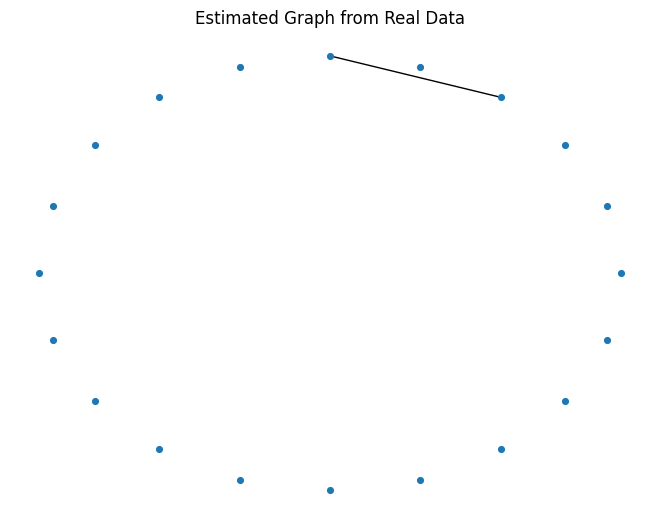

In [19]:
L_est_BA = L_hat.copy()

L_prBA = prune(L_est_BA, 0.01)
adj_BA = np.abs(L_prBA) - np.diag(np.diag(L_prBA))
G_est_BA = nx.from_numpy_array(adj_BA)

nx.draw_circular(G_est_BA, node_size=17)
plt.title("Estimated Graph from Real Data")
plt.show() 

In [18]:
i_indices, j_indices = np.where(L_hat > 0)
positive_entries = [(i, j, L_hat[i, j]) for i, j in zip(i_indices, j_indices)]

#for entry in positive_entries:
    #print(f"Index ({entry[0]}, {entry[1]}) -> Value: {entry[2]}")

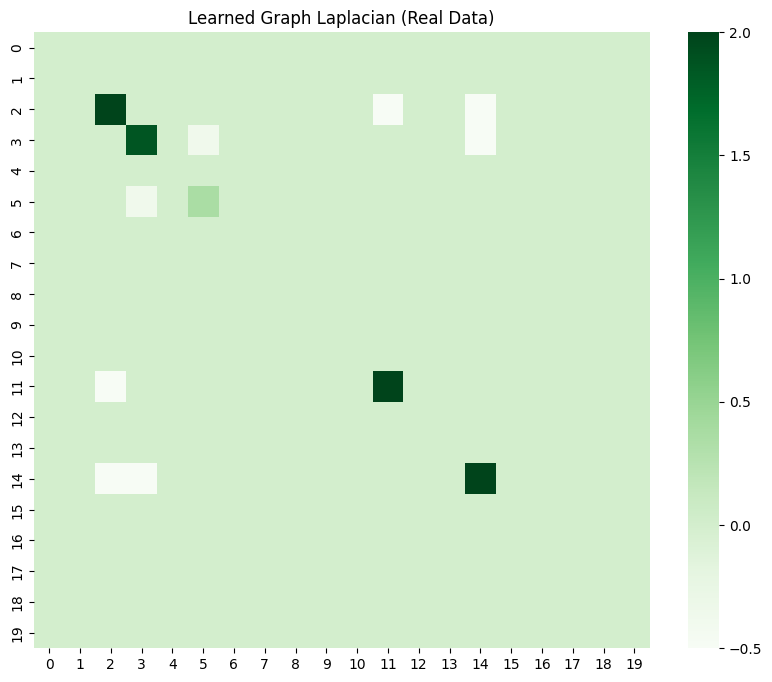

In [33]:
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(L_prBA, cmap="Greens", vmin=-0.5, vmax=2, square=True)
plt.title("Learned Graph Laplacian (Real Data)")
plt.show()


In [35]:
import eval_metrics as met

In [36]:
def findHParams(X_noisy,              # The Observed Signal
                P,                   # The Observed Regressors
                L,               # The partial ground truth laplacian
                x_max = 0.001,            # center x coord of mesh
                y_max = 0.05,            # center y coord of mesh
                epsilon = .1,         # Distance from midpoint to edge of the mesh
                steps = 3,            # Number of recursive steps
                maxiter = 3,          # Max number of iterations GL_Reg will perform to learn a laplacian
                threshold = 10**(-3), # Threshold for pruning insignificant edges
                digits = 4,           # How many decimals to keep in coordinates/metric
                verbose = False):     # Set True to see the path grid search takes 
    # Initializations
    bestResult = glr.GSPRegression(X_noisy, P, x_max,y_max, maxiter, threshold)
    #print(f"bestResult:\n  Result:\n{bestResult[0]}\n  L(estimated):\n{bestResult[3]}\n\n") # TESTING
    maxMeasure = round(met.metricsprf(L, bestResult[0])[2], digits)
    print(f"maxMeasure:\n{maxMeasure}") # TESTING
    if verbose: print("Initial F-Measure is " + str(maxMeasure))
    
    # Create the first 
    X = [.01] + [round(x, digits) for x in np.linspace(x_max - epsilon, x_max + epsilon, 4) if x > 0]
    Y = [.01] + [round(y, digits) for y in np.linspace(y_max - epsilon, y_max + epsilon, 4) if y > 0]
    for i in range(steps):
        for x in X:
            for y in Y:
                curRes = glr.GSPRegression(X_noisy, P, x,y, maxiter, threshold)
                curL = curRes[0]
                curMeasure = round(met.metricsprf(L, curL)[2], digits)
                if verbose: print("Current F-Measure is " + str(curMeasure) + " for x = " + str(x) + " y = " + str(y))
                if curMeasure > maxMeasure:
                    x_max = x
                    y_max = y 
                    bestResult = curRes
                    maxMeasure = curMeasure
                    if verbose: print("New max of " + str(maxMeasure) + " at (" + str(x_max) + ", " + str(y_max) +")")
        if verbose: print("Step " + str(i+1) + " completed.")
        X = [round(i, digits) for i in np.linspace(x_max - epsilon*(.1), x_max + epsilon*(.1), 4) if i > 0]  
        Y = [round(j, digits) for j in np.linspace(y_max - epsilon*(.1), y_max + epsilon*(.1), 4) if j > 0]
    return([x_max, y_max] + bestResult)

results = findHParams(X_noisy, P, L)



maxMeasure:
0.2857


In [20]:
#print(results) #[0.01, 0.01] last result 
def findHParams(X_noisy,              # The Observed Signal
                P0,                   # The Observed Regressors
                Lprime,               # The partial ground truth laplacian
                x_max = 1,            # center x coord of mesh
                y_max = 1,            # center y coord of mesh
                epsilon = .9,         # Distance from midpoint to edge of the mesh
                steps = 3,            # Number of recursive steps
                maxiter = 3,          # Max number of iterations GL_Reg will perform to learn a laplacian
                threshold = 10**(-3), # Threshold for pruning insignificant edges
                digits = 4,           # How many decimals to keep in coordinates/metric
                verbose = False):     # Set True to see the path grid search takes 
    # Initializations
    bestResult = glr.GSPRegression(X_noisy, P0, x_max,y_max, maxiter, threshold)
    # print(f"bestResult:\n  Result:\n{bestResult[0]}\n  L(estimated):\n{bestResult[3]}\n\n") # TESTING
    maxMeasure = round(met.metricsprf(Lprime, bestResult[0])[2], digits)
    # print(f"maxMeasure:\n{maxMeasure}") 
    if verbose: print("Initial F-Measure is " + str(maxMeasure))
    
    # Create the first 
    X = [.01] + [round(x, digits) for x in np.linspace(x_max - epsilon, x_max + epsilon, 4) if x > 0]
    Y = [.01] + [round(y, digits) for y in np.linspace(y_max - epsilon, y_max + epsilon, 4) if y > 0]
    for i in range(steps):
        for x in X:
            for y in Y:
                curRes = glr.GSPRegression(X_noisy, P0, x,y, maxiter, threshold)
                curL = curRes[0]
                curMeasure = round(met.metricsprf(Lprime, curL)[2], digits)
                if verbose: print("Current F-Measure is " + str(curMeasure) + " for x = " + str(x) + " y = " + str(y))
                if curMeasure > maxMeasure:
                    x_max = x
                    y_max = y 
                    bestResult = curRes
                    maxMeasure = curMeasure
                    if verbose: print("New max of " + str(maxMeasure) + " at (" + str(x_max) + ", " + str(y_max) +")")
        if verbose: print("Step " + str(i+1) + " completed.")
        X = [round(i, digits) for i in np.linspace(x_max - epsilon*(.1), x_max + epsilon*(.1), 4) if i > 0]  
        Y = [round(j, digits) for j in np.linspace(y_max - epsilon*(.1), y_max + epsilon*(.1), 4) if j > 0]
    print("-----------------------------------------")
    print("                 Result                  ")
    print("-----------------------------------------")
    print("F-Measure = " + str(maxMeasure) + " at (" + str(x_max) + ", " + str(y_max) + ")")

    return([x_max, y_max] + bestResult) 

In [21]:
results = findHParams(X_noisy, Lprime)

NameError: name 'Lprime' is not defined

In [95]:
def lowertrian(Lap):
    """Extract lower triangular part (excluding diagonal) from a matrix."""
    N = Lap.shape[0]
    return Lap[np.tril_indices(N, k=-1)]

def metricsprf(Lprime, L):

    Lprime_tmp = lowertrian(Lprime)
    L_tmp = lowertrian(L)

    known_indices = [i for i, val in enumerate(Lprime_tmp) if val != 999]

    if len(known_indices) == 0:
        return (-1, -1, -1, -1, -1)
    
    # Extract known values
    Lprime_known = Lprime_tmp[known_indices]
    L_known = L_tmp[known_indices]

    # Convert to binary edge indicators
    true_edges = Lprime_known != 0
    learned_edges = L_known != 0

    if np.sum(learned_edges) == 0:
        return (-1, -1, -1, -1, -1)

    
    precision = metrics.precision_score(true_edges, learned_edges)
    recall = metrics.recall_score(true_edges, learned_edges)
    f1 = metrics.f1_score(true_edges, learned_edges)
    nmi = metrics.normalized_mutual_info_score(true_edges, learned_edges)
    accuracy = metrics.accuracy_score(true_edges, learned_edges)
    
    return precision, recall, f1, nmi, accuracy

def getLhatprime(Lhat_in, Lprime_in):
    
    Lhatprime = Lhat_in.copy()
    for i in range(Lhat_in.shape[0]):
        for j in range(Lhat_in.shape[1]):
            if Lprime_in[i, j] != 999:
                Lhatprime[i, j] = Lprime_in[i, j]
    return Lhatprime

In [96]:
precision, recall, f1, nmi = metricsprf(L, Lprime)
print(precision, recall, f1, nmi) 

NameError: name 'Lprime' is not defined

In [ ]:
from sklearn import metrics
import numpy as np

# Extract the lower triangular part of a matrix (excluding diagonal)
def lowertrian(Lap):
    N = Lap.shape[0]
    return Lap[np.tril_indices(N, k=-1)]


# Return list of ordered pairs (x, y) where matrix value != given value
def getAddressesMatrix(Mx, val):
    Addr = []
    for x in range(len(Mx)):
        for y in range(len(Mx[x])):
            if Mx[x][y] != val:
                Addr.append((x, y))
    return Addr


# Return value at a list of addresses from a matrix
def getAddrVal(Mx, Addr):
    vals = []
    for i in range(len(Addr)):
        x = Addr[i][0]
        y = Addr[i][1]
        vals.append(Mx[x][y])
    return vals


# Return list of indices where vector values != val
def getAddressesVector(V, val):
    Addr = []
    for i in range(len(V)):
        if V[i] != val:
            Addr.append(i)
    return Addr



In [38]:
def lowertrian(Lap):
    """Extract lower triangular part (excluding diagonal) from a matrix."""
    N = Lap.shape[0]
    return Lap[np.tril_indices(N, k=-1)]

def metricsprf(Lprime, L):

    Lprime_tmp = lowertrian(Lprime)
    L_tmp = lowertrian(L)

    known_indices = [i for i, val in enumerate(Lprime_tmp) if val != 999]

    if len(known_indices) == 0:
        print("No known entries in ground truth Laplacian.")
        return (-1, -1, -1, -1, -1)
    
    # Extract known values
    Lprime_known = Lprime_tmp[known_indices]
    L_known = L_tmp[known_indices]

    # Convert to binary edge indicators
    true_edges = Lprime_known != 0
    learned_edges = L_known != 0

    if np.sum(learned_edges) == 0:
        return (-1, -1, -1, -1, -1)

    
    precision = metrics.precision_score(true_edges, learned_edges)
    recall = metrics.recall_score(true_edges, learned_edges)
    f1 = metrics.f1_score(true_edges, learned_edges)
    nmi = metrics.normalized_mutual_info_score(true_edges, learned_edges)
    accuracy = metrics.accuracy_score(true_edges, learned_edges)
    
    return precision, recall, f1, nmi, accuracy

def getLhatprime(Lhat_in, Lprime_in):
    
    Lhatprime = Lhat_in.copy()
    for i in range(Lhat_in.shape[0]):
        for j in range(Lhat_in.shape[1]):
            if Lprime_in[i, j] != 999:
                Lhatprime[i, j] = Lprime_in[i, j]
    return Lhatprime


In [39]:
def lowertrian(Lap):

    N = Lap.shape[0]
    return Lap[np.tril_indices(N, k=-1)]

def metricsprf(L, L_hat):

    # Remove diagonal and take lower triangle
    L0_lower = lowertrian(L)
    L_lower = lowertrian(L_hat)

    edges_groundtruth = L0_lower != 0
    edges_learned = L_lower != 0

    # If no edges learned, return invalid scores
    if np.sum(edges_learned) == 0:
        return -1, -1, -1, -1

    # Compute metrics
    precision = metrics.precision_score(edges_groundtruth, edges_learned)
    recall = metrics.recall_score(edges_groundtruth, edges_learned)
    f1 = metrics.f1_score(edges_groundtruth, edges_learned)
    nmi = metrics.normalized_mutual_info_score(edges_groundtruth, edges_learned)

    return precision, recall, f1, nmi


In [40]:
precision, recall, f1, nmi = metricsprf(L, L_hat)
print("F1-score:", f1)


F1-score: 1.0


In [42]:
L_real = L  # real Laplacian matrix (numpy array)
rho = 0.6    

# Get lower triangle of matrix
def toLowerTriangularM(L_real):
    print(L_real[1:5])
    LTM = []
    for i in range(1, L_real.shape[0]):
        row = []
        for j in range(i):
            row.append(L_real[i][j])
        LTM.append(row)
    print(LTM[1:5])
    return LTM 

#LTM = toLowerTriangularM(L_real) ## calling the func. 

In [ ]:
# Flatten lower triangle into vector
def listlistTOvector(LTM):
    V = []
    for row in LTM:
        V.extend(row)
    return V
    

# Reshape vector back into lower triangle list of lists
def LTVectorTOlistlist(V):
    List = []
    row = []
    count = 1
    for val in V:
        row.append(val)
        if len(row) == count:
            List.append(row.copy())
            row.clear()
            count += 1
    return List

    
N = L_prBA.shape[0]
print('N = ', N) # num of nodes in sample 
k = int(N * (N - 1) / 2) 
print('k = ', k) # # total number of locations in lower diagonal matrix of L
s_k = round(k * rho) 
print('s_k = ', s_k) #number of values to copy from complete L to partially known L (L', Lprime)

import random 
# Randomly mask unknown values in lower triangle with 999
def LprimeLT_from_Llt(L_real, k, s_k):
    LltV = listlistTOvector(L_real)
    j = k - s_k  # number of unknowns

    for i in range(j):
        while True:
            random.seed(12345)
            rand_index = random.randint(0, len(LltV) - 1)
            if LltV[rand_index] != 999:
                LltV[rand_index] = 999
                break

    return LTVectorTOlistlist(LltV)
    

# Build symmetric Lprime with 999 placeholders
def Lprime_from_LprimeLT(L, LprimeLT):
    Lprime = np.full_like(L, 999, dtype=float)
    N = L.shape[0]

    for i in range(N - 1):
        for j in range(len(LprimeLT[i])):
            if LprimeLT[i][j] != 999:
                Lprime[i + 1][j] = LprimeLT[i][j]
                Lprime[j][i + 1] = LprimeLT[i][j]

    
    # Diagonal reconstruction
    for i in range(N):
        row_sum = 0
        valid = True
        for j in range(N):
            if i != j:
                if Lprime[i][j] == 999:
                    valid = False
                    break
                row_sum += Lprime[i][j]
        if valid:
            Lprime[i][i] = row_sum

    return Lprime


# MAIN: Generate Lprime from full L using a known percentage
def getLprime(L, rho):
    N = L.shape[0]
    k = int(N * (N - 1) / 2)
    s_k = round(k * rho)

    Llt = toLowerTriangularM(L)
    LprimeLT = LprimeLT_from_Llt(Llt, k, s_k)
    return Lprime_from_LprimeLT(L, LprimeLT)

Lprime = getLprime(L, rho) 

N =  20
k =  190
s_k =  114
[[ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          7.03932054  0.          0.          0.
   0.          0.          0.          0.          0.         -5.94303338
   0.          0.         -1.09628715  0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          2.96067914  0.         -1.45292855
   0.          0.          0.          0.          0.          0.
   0.          0.         -1.50775058  0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.        ]]
[[np.float64(0.0), np.float64(0.0)], [np.float64(0.0), 

In [ ]:
def GL_RP(Signals, Regressors, Result, Lprime, normL_true):
    Lhat = glr.GSPRegression(Signals, Regressors, Result[0], Result[1])[0]
    Lhat_prime = glr.getLhatprime(Lhat, Lprime)
    glr.metricsprf(normL_true, Lhat_prime)



In [ ]:
print(getLprime(L_real, 2))

In [16]:
import matplotlib.pyplot as matplt
import math # for NaN
import random
import time # for time

## converts typeListList to typeVector/typeArray/typeList
# input: LL - type: list of lists / array of lists
# output: v - type: vector / list
def listlistTOvector (LL):
    v = []
    for i in range(len(LL)):
        for j in range(len(LL[i])):
            v.append(LL[i][j])
    return v

## converts typeltVector to typeListList
# input: LTV - type: (lower triangular) vector / list
# output: List - type: (lower triangular) list of lists
def LTVectorTOlistlist (LTV):
    list = []
    List = []
    row = 0
    col = 0
    # n =  # degree of matrix from which V was derived or to which V is transformed
    for i in range(len(LTV)):
        row += 1
        list.append(LTV[i])
        if row == col + 1:
            col += 1
            row = 0
            List.append(list.copy())
            list.clear()
    return List

## returns L lower triangle triangle-formatted matrix
# input: M - type: matrix
# output: LTM - (lower triangular) matrix
def toLowerTriangularM(M):
    tempList = []
    LTM = []
    for i in range(1, M.shape[0]):
        for j in range(i):
            tempList.append(M[i][j])
        LTM.append(tempList)
        tempList = []
    return LTM

# returns Lprime lower triangular matrix
# input:
#   Llt (L lower-triangular) - type: list of lists
#   k - type: int - number (int) of known edges in L
#   s_k - type: int - number (int) of known edges from Llt
# output: LprimeLT = LTVectorTOlistlist(LprimeLTV) - type: list of lists
def LprimeLT_from_Llt(Llt, k, s_k):
    LltV = listlistTOvector(Llt)
    LprimeLTV = LltV # use for loop (element deletes)
    j = k - s_k # number of unkown edges in LprimeLT
    randNum = 0 # index...

    # for: deletes values from copy(Llt) to make LprimeLT
    for i in range(j):
        repeat = False

        while not repeat:
            random.seed(time.time() + i) # seed change for TRULY random number
            # random.seed(777 + i) # seed change for random REPETITIVE number
            randNum = random.randint(0,len(LltV) - 1) # index

            if LprimeLTV[randNum] == 999:
                repeat = False
                i += 1 # changes val of i to change val of rand.seed
            else:
                LprimeLTV[randNum] = 999
                repeat = True

    return LTVectorTOlistlist(LprimeLTV) # returns LprimeLT


################## FINISH DESCRIPTION ##################
# triangular matrix to full NxN matrix
def Lprime_from_LprimeLT(L, LprimeLT):
    Lprime = L.copy()
    # initializing Lprime
    for i in range(len(L.copy())):
        for j in range(len(L[i].copy())):
            Lprime[i][j] = 999

    N = Lprime.shape[0]

    # loop: copies LprimeLT to Lprime
    for i in range(N - 1):
        for j in range(len(LprimeLT[i])):
            if LprimeLT[i][j] != 999:
                Lprime[i + 1][j] = LprimeLT[i][j]

    # symmetrize matrix
    for i in range(len(L.copy())):
        for j in range(len(L[i].copy())):
            if (Lprime[i][j] != 999):
                Lprime[j][i] = Lprime[i][j]

    diagSum = 0
    # loop: compute diagonal values, if possible (if no other unkown in a row/col)
    for i in range(len(L.copy())):
        # loop:
        for j in range(len(L[i].copy())):
            # if value at diagonal element is unkown
            if (i != j):
                if (L[i][j] == 999): # if value at diagonal element is unkown
                    break
                diagSum += L[i][j] # running sum for diag elem

            # if: just summed last element of row, replace diagonal element
            if (j == len(L[i].copy()) - 1):
                L[i][i] = abs(diagSum)
        diagSum = 0 # reset diagSum

    return Lprime


### MAIN FUNCTION: getLprime

def getLprime(
    L,                  # Laplacian (known groundtruth) input
    # N,                  # number of nodes on graph G
    # k,                  # number of elements in Llt
    rho,                # percent of L known
    # s_k,                # number of known elements from Llt
    ):

    N = L.shape[0]
    # define k, s_k
    k = int(N * (N - 1) / 2)
    s_k = round(k * rho)

    # print("Unkown Value Placeholders: 999")

    # Llt from L
    Llt = toLowerTriangularM(L)
    # print(f"Llt:\n{Llt}") # TESTING

    # LprimeLT from Llt
    LprimeLT = LprimeLT_from_Llt(Llt, k, s_k)
    # print(f"LprimeLT:\n{LprimeLT}") # TESTING

    # Lprime from LprimeLT
    # print(f"Lprime_from_LprimeLT(L, LprimeLT):\n{Lprime_from_LprimeLT(L, LprimeLT)}") # TESTING
    return Lprime_from_LprimeLT(L, LprimeLT)

#Synthetic Graph/Info 
G_BA = nx.barabasi_albert_graph(20,1,seed = 777)
L_BA = nx.laplacian_matrix(G_BA).toarray()
normL_BA = (L_BA.shape[0]/np.trace(L_BA))*L_BA


#print(getLprime(L_BA, 0.2))


[[999 999 999 999 999 999 999 999 999 999 999 999 999 999 999 999   0 999
    0 999]
 [999 999 999   0 999   0 999 999   0 999   0 999 999 999   0   0 999 999
    0 999]
 [999 999 999 999 999 999 999  -1 999 999 999   0 999 999 999 999 999 999
    0 999]
 [999   0 999 999 999 999 999   0 999 999 999   0 999 999 999   0 999 999
  999 999]
 [999 999 999 999 999 999 999 999   0 999 999   0   0   0 999 999 999 999
   -1 999]
 [999   0 999 999 999 999 999 999 999 999 999 999 999 999 999 999   0 999
    0   0]
 [999 999 999 999 999 999 999 999 999   0 999 999 999 999   0 999 999 999
  999 999]
 [999 999  -1   0 999 999 999 999 999 999 999 999 999 999 999 999 999 999
  999 999]
 [999   0 999 999   0 999 999 999 999   0 999 999 999 999 999 999 999 999
  999 999]
 [999 999 999 999 999 999   0 999   0 999 999   0 999 999 999 999   0 999
  999 999]
 [999   0 999 999 999 999 999 999 999 999 999 999   0 999 999 999   0 999
  999 999]
 [999 999   0   0   0 999 999 999 999   0 999 999 999 999   0 999

In [20]:
Lprime = np.full(D.shape, 999)  # default to 999
Lprime[(D < 40000) & (D > 0)] = -1
Lprime[D > 193121] = 0
#print(Lprime)

[[ -1 999 999  -1  -1   0   0  -1  -1   0   0   0   0   0   0  -1  -1  -1
   -1   0 999]
 [ -1 999 999 999  -1   0 999 999 999   0   0   0   0 999   0 999 999 999
  999 999 999]
 [ -1  -1 999 999  -1   0   0  -1  -1   0   0   0   0 999   0  -1  -1  -1
   -1 999 999]
 [ -1  -1  -1  -1 999   0   0 999  -1   0   0   0   0 999   0 999 999 999
  999 999 999]
 [ -1   0   0   0   0 999   0   0   0  -1  -1 999 999 999 999   0   0   0
    0   0   0]
 [ -1   0 999   0   0   0 999   0   0   0   0 999 999 999 999   0   0   0
    0 999 999]
 [ -1  -1 999  -1 999   0   0 999  -1   0   0   0   0   0   0  -1  -1  -1
   -1   0 999]
 [ -1  -1 999  -1  -1   0   0  -1 999   0   0   0   0   0   0  -1  -1  -1
   -1   0 999]
 [ -1   0   0   0   0  -1   0   0   0 999  -1 999 999 999   0   0   0   0
    0   0   0]
 [ -1   0   0   0   0  -1   0   0   0  -1 999 999 999 999   0   0   0   0
    0   0   0]
 [ -1   0   0   0   0 999 999   0   0 999 999 999 999 999  -1   0   0   0
    0 999   0]
 [ -1   0   0   0   0

In [ ]:
NM = np.sum()

mean_sq_error = (L - L_hat)* NM 

frobenius_squared = np.sum(mean_sq_error**2)

num_sample_observed = np.sum(NM)

mse_masked = frobenius_squared / num_sample_observed

#print(mse_masked)

In [10]:
!pip install geodatasets
!pip install contextily
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import geodatasets

In [11]:
import contextily as ctx
Nlocations = pd.read_csv("/Users/chrisduran/Desktop/315/NOAA_locations.csv")

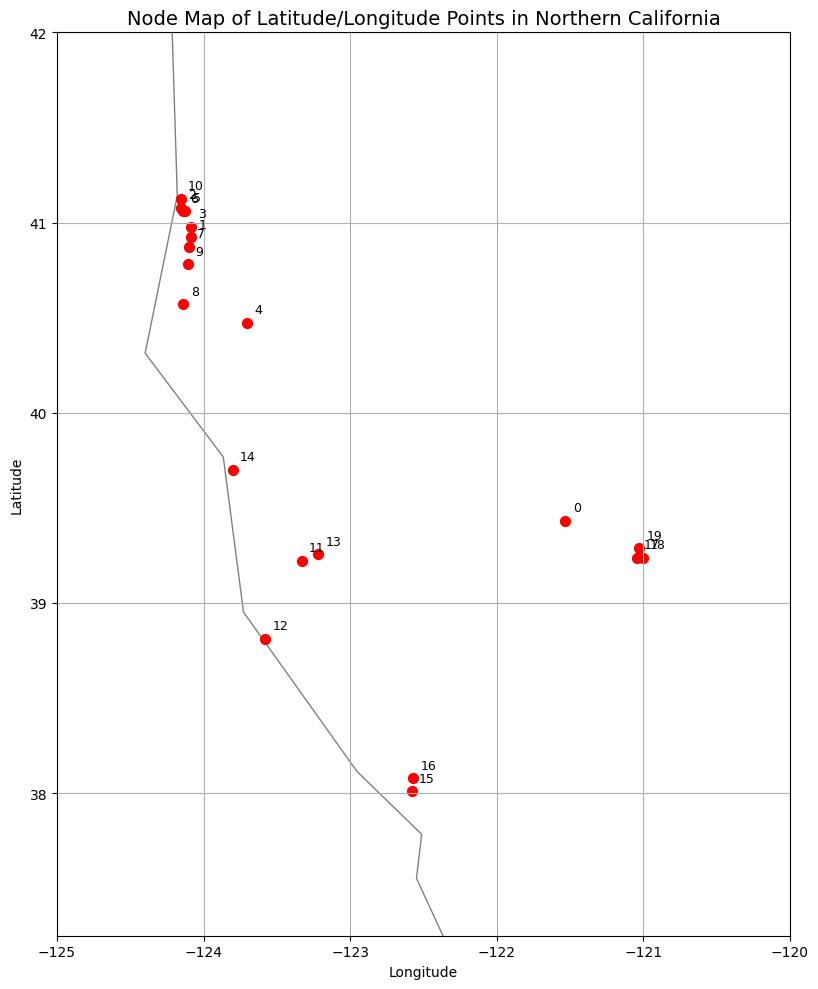

In [52]:
# Create a GeoDataFrame from lat/lon
gdf = gpd.GeoDataFrame(
    Nlocations,
    geometry=gpd.points_from_xy(Nlocations["LONGITUDE"], Nlocations["LATITUDE"]),
    crs="EPSG:4326")

# Load a world basemap and filter to USA
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url) 
usa = world[world["ADMIN"] == "United States of America"]

fig, ax = plt.subplots(figsize=(10, 10))

    
    
usa.plot(ax=ax, color='white', edgecolor='gray')
ax.set_xlim(-125, -120)  # Longitudes
ax.set_ylim(37.25, 42)      # Latitudes

    # Plot the nodes
gdf.plot(ax=ax, color='red', markersize=50)

    # Label each point with an index
for idx, row in gdf.iterrows():
    ax.text(row.geometry.x + 0.05, row.geometry.y + 0.05, str(idx), fontsize=10, color='black')

ax.set_title("Node Map of Latitude/Longitude Points in Northern California", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.savefig("norcal_node_map.png", dpi=100)
plt.show()


In [18]:
wwdlocations = pd.read_csv("/Users/chrisduran/Desktop/315/wwd_locations.csv")  

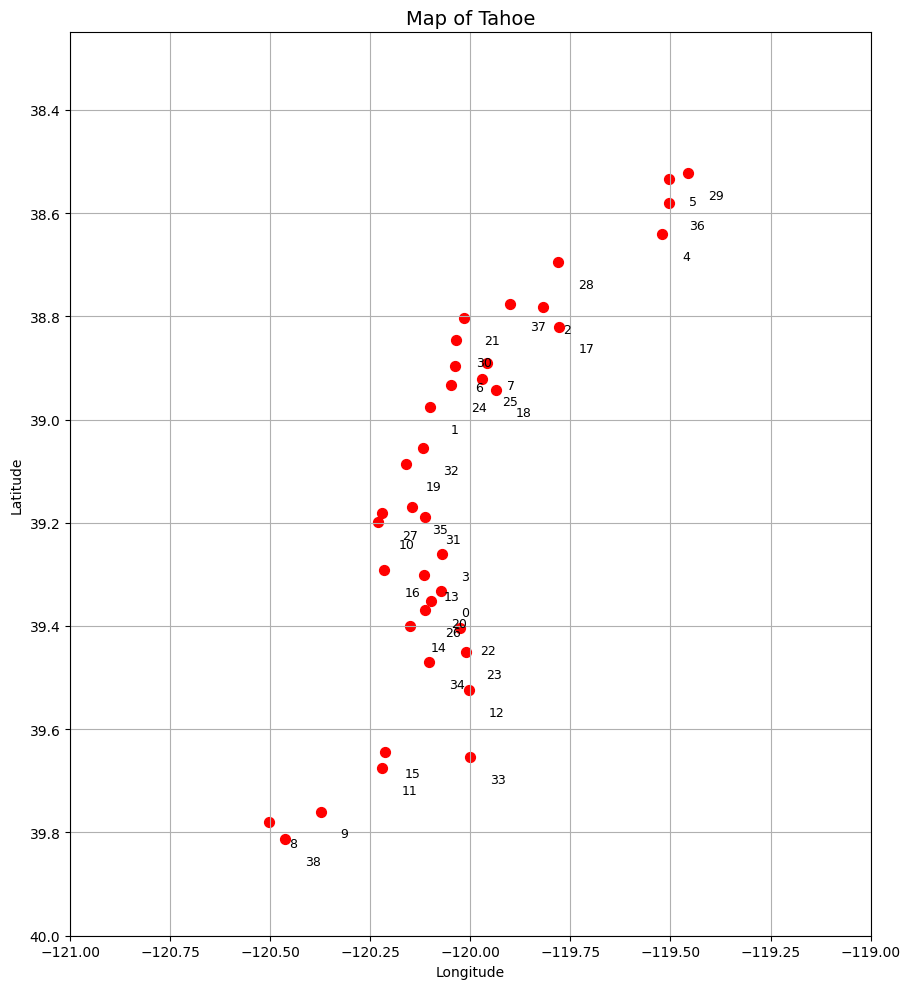

In [51]:
# Create a GeoDataFrame from lat/lon
gdf_2 = gpd.GeoDataFrame(
    wwdlocations,
    geometry=gpd.points_from_xy(wwdlocations["Longitude"], wwdlocations["Latitude"]),
    crs="EPSG:4326")

# Load a world basemap and filter to USA
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url) 
usa = world[world["ADMIN"] == "United States of America"]

fig, ax = plt.subplots(figsize=(10, 10))

    
    
usa.plot(ax=ax, color='white', edgecolor='gray')
ax.set_xlim(-121, -119)  # Longitudes
ax.set_ylim(40, 38.25)      # Latitudes

    # Plot the nodes
gdf_2.plot(ax=ax, color='red', markersize=50)

    # Label each point with an index
for idx, row in gdf_2.iterrows():
    ax.text(row.geometry.x + 0.05, row.geometry.y + 0.05, str(idx), fontsize=9, color='black')

ax.set_title("Map of Tahoe", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.savefig("tahoe_node_map.png", dpi=100)
plt.show()

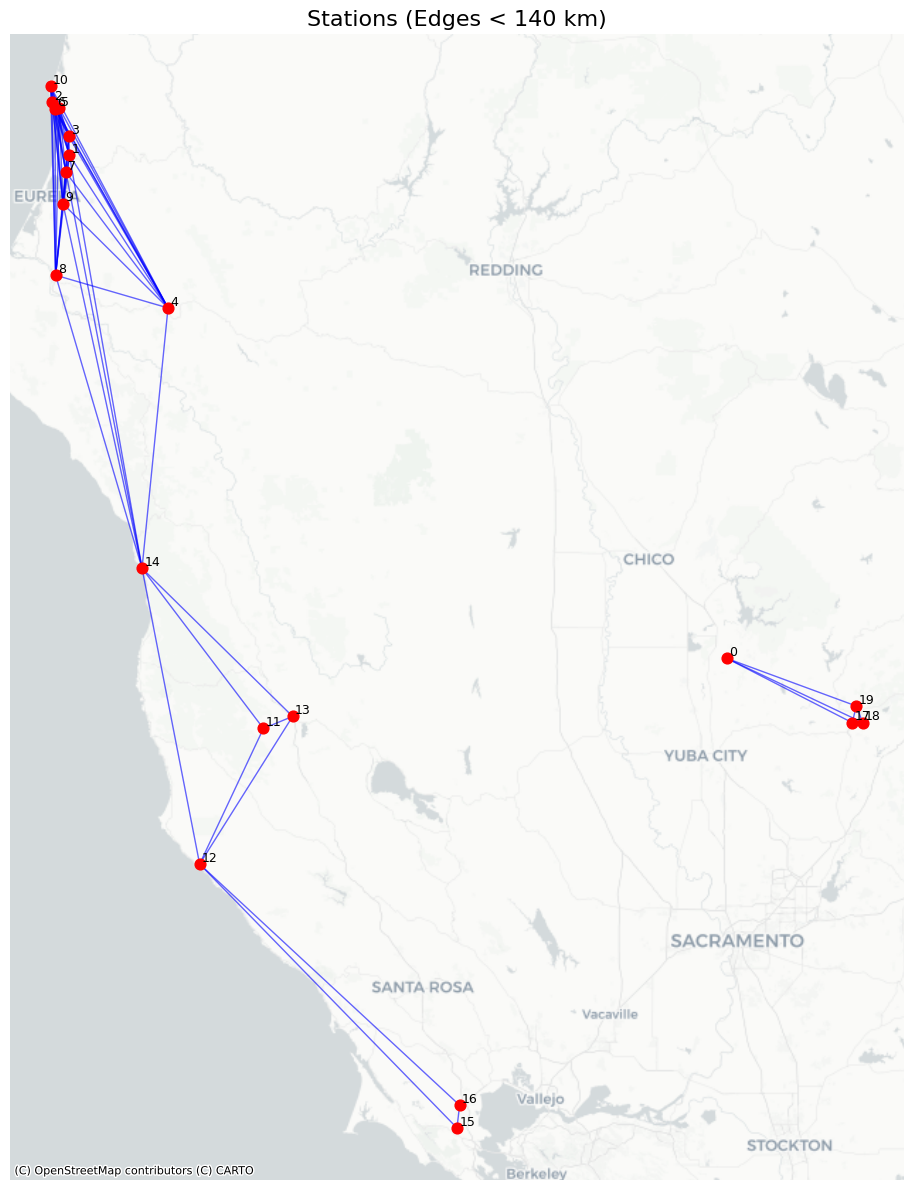

In [25]:

import matplotlib.pyplot as plt
from geopy.distance import geodesic
from shapely.geometry import LineString

# Load your data
# Nlocations = pd.read_csv("your_file.csv")

# Create a GeoDataFrame from lat/lon
gdf = gpd.GeoDataFrame(
    Nlocations,
    geometry=gpd.points_from_xy(Nlocations["LONGITUDE"], Nlocations["LATITUDE"]),
    crs="EPSG:4326"  # WGS84
)

# Calculate edges between stations < 200 km apart
edges = []
for i in range(len(gdf)):
    for j in range(i + 1, len(gdf)):
        coord_i = (gdf.iloc[i].geometry.y, gdf.iloc[i].geometry.x)
        coord_j = (gdf.iloc[j].geometry.y, gdf.iloc[j].geometry.x)
        dist_km = geodesic(coord_i, coord_j).km
        if dist_km < 140:
            line = LineString([gdf.iloc[i].geometry, gdf.iloc[j].geometry])
            edges.append(line)

# Convert edges to GeoDataFrame and reproject both to Web Mercator
edges_gdf = gpd.GeoDataFrame(geometry=edges, crs="EPSG:4326")
gdf = gdf.to_crs(epsg=3857)
edges_gdf = edges_gdf.to_crs(epsg=3857)

# Plot the map
fig, ax = plt.subplots(figsize=(12, 12))

# Plot edges
edges_gdf.plot(ax=ax, color='blue', linewidth=1, alpha=0.6, zorder=1)

# Plot nodes
gdf.plot(ax=ax, color='red', markersize=60, zorder=2)

# Add labels
for idx, row in gdf.iterrows():
    ax.text(row.geometry.x + 1000, row.geometry.y + 1000, str(idx), fontsize=9, color='black', zorder=3)

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=8)

# Clean up
ax.set_axis_off()
ax.set_title("Stations (Edges < 140 km)", fontsize=16)
plt.tight_layout()
plt.savefig("norcal_station_graph.png", dpi=300)
plt.show()


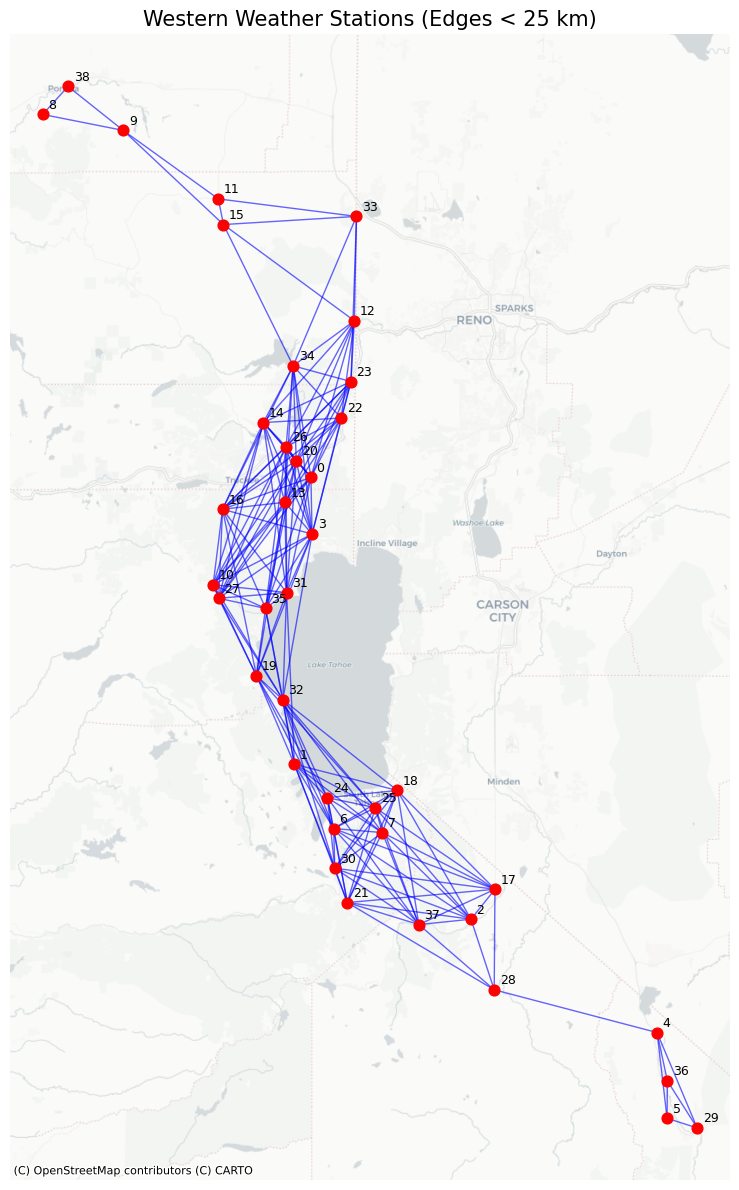

In [27]:


gdf_2 = gpd.GeoDataFrame(
    wwdlocations,
    geometry=gpd.points_from_xy(wwdlocations["Longitude"], wwdlocations["Latitude"]),
    crs="EPSG:4326")


edges = []
for i in range(len(gdf_2)):
    for j in range(i + 1, len(gdf_2)):
        coord_i = (gdf_2.iloc[i].geometry.y, gdf_2.iloc[i].geometry.x)
        coord_j = (gdf_2.iloc[j].geometry.y, gdf_2.iloc[j].geometry.x)
        if geodesic(coord_i, coord_j).km < 25:
            edges.append(LineString([gdf_2.iloc[i].geometry, gdf_2.iloc[j].geometry]))

edges_gdf = gpd.GeoDataFrame(geometry=edges, crs="EPSG:4326")

gdf_2 = gdf_2.to_crs(epsg=3857)
edges_gdf = edges_gdf.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(12, 12))

# Plot edges below
edges_gdf.plot(ax=ax, color='blue', linewidth=1, alpha=0.6)

# Plot station points
gdf_2.plot(ax=ax, color='red', markersize=60, zorder=2)

# Add station labels
for idx, row in gdf_2.iterrows():
    ax.text(row.geometry.x + 1000, row.geometry.y + 1000, str(idx), fontsize=9, color='black', zorder=3)

# Add basemap (e.g., CartoDB for a clean background)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=10)


ax.set_axis_off()
ax.set_title("Western Weather Stations (Edges < 25 km)", fontsize=15)
plt.tight_layout()
plt.savefig("tahoe_graph_with_map.png", dpi=300)
plt.show()


In [28]:
import os
print(os.getcwd())


/Users/chrisduran/Desktop/math_351/GL_Reg/GL_Reg


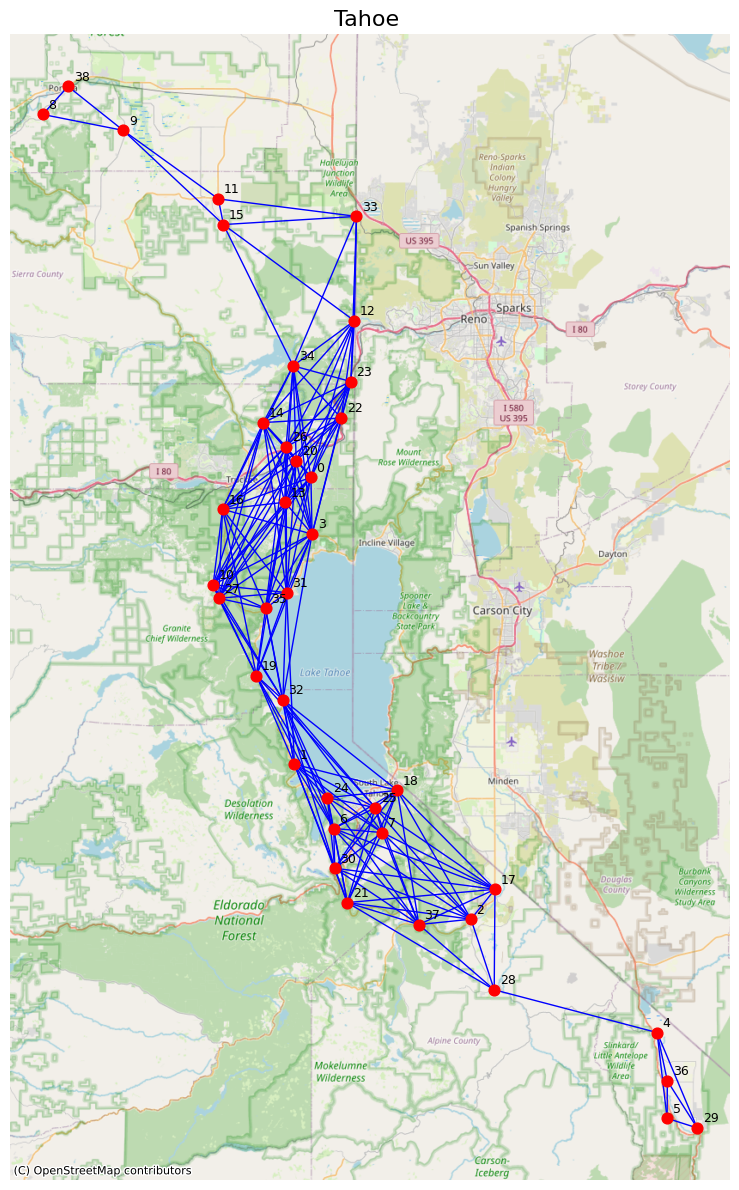

In [43]:


# Convert coordinates to GeoDataFrame
gdf = gpd.GeoDataFrame(
    wwdlocations,
    geometry=gpd.points_from_xy(wwdlocations["Longitude"], wwdlocations["Latitude"]),
    crs="EPSG:4326"
)

# Reproject for contextily
gdf = gdf.to_crs(epsg=3857)

# Build edge GeoDataFrame
edges = []
for i, j in itertools.combinations(range(len(gdf)), 2):
    coord1 = (wwdlocations.loc[i, 'Latitude'], wwdlocations.loc[i, 'Longitude'])
    coord2 = (wwdlocations.loc[j, 'Latitude'], wwdlocations.loc[j, 'Longitude'])
    if geodesic(coord1, coord2).km < 25:
        edges.append(LineString([gdf.geometry.iloc[i], gdf.geometry.iloc[j]]))

edge_gdf = gpd.GeoDataFrame(geometry=edges, crs=gdf.crs)

# Plot
fig, ax = plt.subplots(figsize=(12, 12))

edge_gdf.plot(ax=ax, color='blue', linewidth=1, zorder=1)
gdf.plot(ax=ax, color='red', markersize=60, zorder=2)

for idx, row in gdf.iterrows():
    ax.text(row.geometry.x + 1000, row.geometry.y + 1000, str(idx), fontsize=9, color='black', zorder=3)

# Use a colorful basemap (ESRI or OpenStreetMap)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=gdf.crs, zoom=10)

ax.set_axis_off()
ax.set_title("Tahoe ", fontsize=16)
plt.tight_layout()
plt.savefig("tahoe_colorful_map.png", dpi=300)
plt.show()


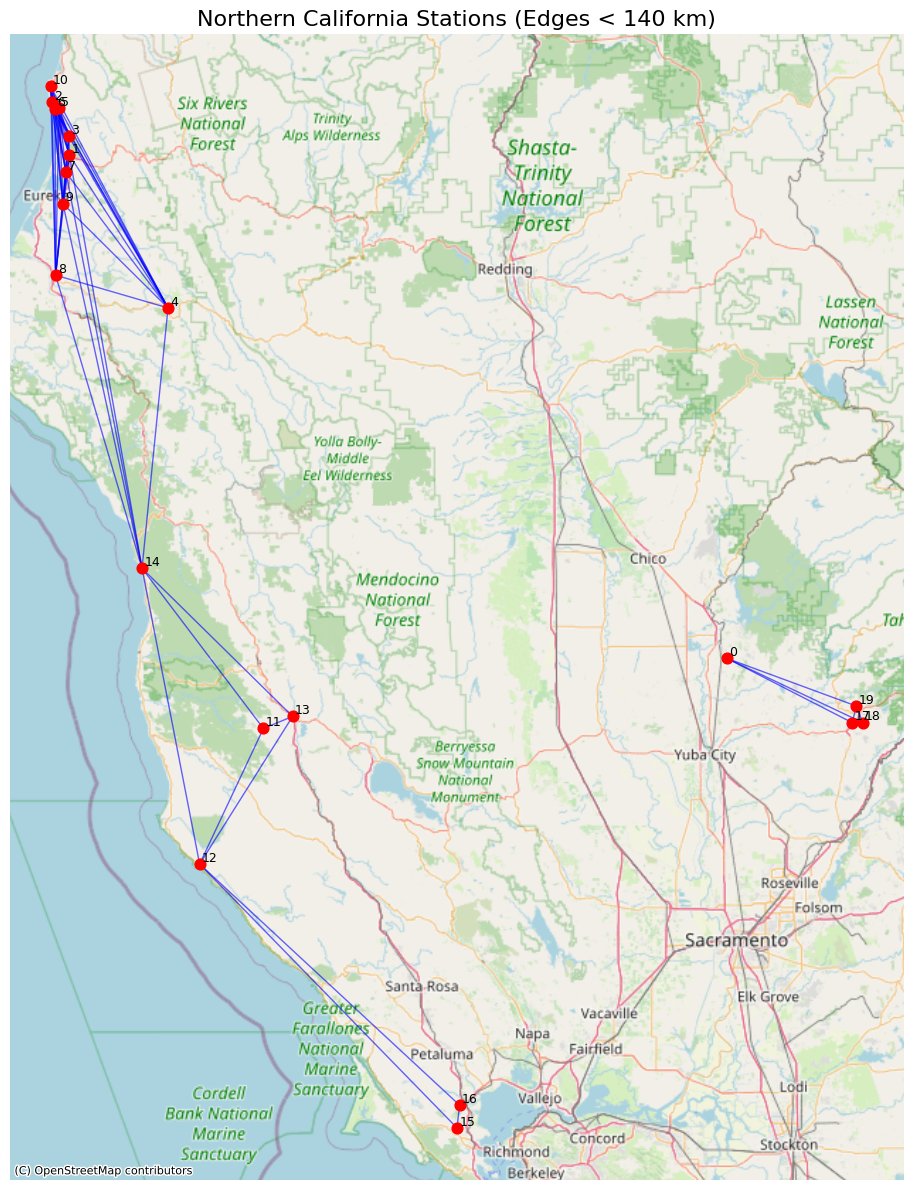

In [41]:

from geopy.distance import geodesic
from shapely.geometry import LineString

# Create GeoDataFrame from coordinates
gdf = gpd.GeoDataFrame(
    Nlocations,
    geometry=gpd.points_from_xy(Nlocations["LONGITUDE"], Nlocations["LATITUDE"]),
    crs="EPSG:4326"  # WGS84
)

# Generate edges for stations within 140 km
edges = []
for i in range(len(gdf)):
    for j in range(i + 1, len(gdf)):
        coord_i = (gdf.iloc[i].geometry.y, gdf.iloc[i].geometry.x)
        coord_j = (gdf.iloc[j].geometry.y, gdf.iloc[j].geometry.x)
        if geodesic(coord_i, coord_j).km < 140:
            edges.append(LineString([gdf.iloc[i].geometry, gdf.iloc[j].geometry]))

# Convert to Web Mercator for basemap compatibility
gdf = gdf.to_crs(epsg=3857)
edges_gdf = gpd.GeoDataFrame(geometry=edges, crs="EPSG:4326").to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(12, 12))

# Plot edges and nodes
edges_gdf.plot(ax=ax, color='blue', linewidth=1, alpha=0.6, zorder=1)
gdf.plot(ax=ax, color='red', markersize=60, zorder=2)

# Add labels
for idx, row in gdf.iterrows():
    ax.text(row.geometry.x + 1000, row.geometry.y + 1000, str(idx), fontsize=9, color='black', zorder=3)

# Add colorful basemap (OpenStreetMap)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=gdf.crs, zoom=8)

# Finalize plot
ax.set_axis_off()
ax.set_title("Northern California Stations (Edges < 140 km)", fontsize=16)
plt.tight_layout()
plt.savefig("norcal_station_graph_colored.png", dpi=300)
plt.show()
